<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
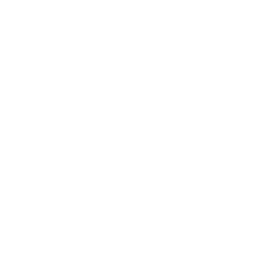
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Diagnostic de la perturbation du réacteur chimique</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Identifier les variables à l'origine du dépassement T2 du réacteur pendant l'incident &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Résumé exécutif

Un réacteur agité en continu (CSTR) a dérivé vers une perturbation
thermique lorsque son alimentation en liquide de refroidissement s'est
dégradée. En fonctionnement normal, le débit de liquide de
refroidissement, la température du réacteur et la température de la
chemise évoluent ensemble le long d'un seul axe de charge du procédé.
Nous construisons un modèle MVP à trois composantes sur 100
observations de fonctionnement normal, puis nous évaluons 100
observations de la perturbation par rapport à ce modèle avec
`PROC MVPDIAGNOSE`. La décomposition de la statistique *T*-carré de
Hotelling en contributions par variable isole le trio couplé
thermiquement — `jacket_temp`, `coolant_flow` et `reactor_temp` — comme
les variables à l'origine du dépassement, orientant directement les
opérations vers le sous-système de refroidissement.


## Sources de données

| Jeu de données | Rôle | Observations |
|---|---|---|
| `reactor_normal` | Données d'entraînement en fonctionnement normal pour le modèle MVP | 100 |
| `reactor_upset` | Observations de l'incident évaluées par rapport au modèle | 100 |

Les cinq variables mesurées sont `reactor_temp` (°C), `coolant_flow`
(L/min), `jacket_temp` (°C), `feed_conc` (g/L) et `pressure` (bar).
Les deux jeux de données sont simulés à partir d'une même charge de
procédé latente commune, si bien que les données normales présentent
la même structure de corrélation qu'un CSTR réel ; la perturbation
injecte une perte d'alimentation en liquide de refroidissement qui
brise cette structure.


## Étape 1 — Entraîner le modèle MVP en fonctionnement normal

Le fonctionnement normal est régi par une charge de procédé latente :
une charge plus élevée réduit le débit de liquide de refroidissement
tout en augmentant les températures du réacteur et de la chemise.
`PROC MVPMODEL` extrait trois composantes principales des 100
observations normales et les conserve avec `OUTMODEL=` afin que
l'étape de diagnostic puisse évaluer de nouvelles données par rapport
à la même référence.


In [1]:
DONNÉES reactor_normal;
  APPELER streaminit(7);
  FAIRE t = 1 JUSQU_À 100;
    LOAD = rand('normal', 0, 1);                 /* charge de procédé latente */
    reactor_temp = 85.0 + 2.5*LOAD + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*LOAD + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*LOAD + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*LOAD + rand('normal', 0, 0.05);
    SORTIE;
  FIN;
EXÉCUTER;

PROC MVPMODEL DONNÉES=reactor_normal outmodel=reactor_model;
  VAR reactor_temp coolant_flow jacket_temp feed_conc pressure;
  ÉTIQUETTE reactor_temp="Température du réacteur"
        coolant_flow="Débit du liquide de refroidissement"
        jacket_temp="Température de la chemise"
        feed_conc="Concentration d'alimentation"
        pressure="Pression";
  ncomp=3;
EXÉCUTER;



                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
         Température du réacteurDébit du liquide de refroidissementTempérature de la chemiseConcentration d'alimentation  Pression
  Température du réacteur    1.0000   -0.9611    0.9530   -0.0726    0.9662
  Débit du liquide de refroidissement   -0.9611    1.0000   -0.9636    0.0281   -0.9712
  Température de la chemise    0.9530   -0.9636    1.0000    0.0008    0.9720
  Concentration d'alimentation   -0.0726    0.0281    0.0008    1.0000   -0.0326
  Pression    0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321      


NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## Étape 2 — Évaluer l'incident et décomposer le *T*-carré

La perturbation réduit le débit de liquide de refroidissement d'environ
12 L/min tandis que les températures du réacteur et de la chemise
grimpent — le couplage normal débit/température est rompu.
`PROC MVPDIAGNOSE` évalue chaque observation de l'incident par rapport
au modèle de référence, en écrivant les scores standardisés et les
résidus dans `OUT=` et les contributions au *T*-carré par variable dans
`OUTCONTRIB=`. Chaque observation dépasse largement la limite de
contrôle, confirmant une excursion multivariée soutenue plutôt qu'un
bruit isolé.


In [2]:
DONNÉES reactor_upset;
  APPELER streaminit(101);
  FAIRE t = 1 JUSQU_À 100;
    LOAD = rand('normal', 0, 1);
    /* La pompe de refroidissement se dégrade : le débit chute, les températures s'emballent */
    reactor_temp = 85.0 + 2.5*LOAD + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*LOAD + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*LOAD + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*LOAD + rand('normal', 0, 0.05);
    obs_time = t;
    SORTIE;
  FIN;
EXÉCUTER;

PROC MVPDIAGNOSE DONNÉES=reactor_upset MODÈLE=reactor_model
                 out=reactor_scores;
  VAR reactor_temp coolant_flow jacket_temp feed_conc pressure;
  id obs_time;
  ÉTIQUETTE reactor_temp="Température du réacteur"
        coolant_flow="Débit du liquide de refroidissement"
        jacket_temp="Température de la chemise"
        feed_conc="Concentration d'alimentation"
        pressure="Pression";
  outcontrib=reactor_contrib;
EXÉCUTER;



                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100
  Variables Diagnosed: Température du réacteur, Débit du liquide de refroidissement, Température de la chemise, Concentration d'alimentation, Pression

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more





NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## Étape 3 — Classer les contributions moyennes

`OUTCONTRIB=` écrit une ligne par observation évaluée avec une colonne
`<variable>_CONTRIB` pour chaque variable du procédé. Faire la moyenne
de ces colonnes donne la contribution moyenne de chaque variable à
l'incident ; une transposition remodèle le résumé à une ligne en un
tableau variable/valeur bien ordonné qui classe les facteurs de
défaillance.


In [3]:
PROC MEANS DONNÉES=reactor_contrib mean SANS_IMPRESSION;
  VAR reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  SORTIE out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
EXÉCUTER;

PROC TRANSPOSE DONNÉES=contrib_means out=contrib_long name=metric;
  VAR mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
EXÉCUTER;

/* Associe des noms de variables lisibles et la valeur de contribution moyenne */
DONNÉES contrib_ranked;
  DÉFINIR contrib_long;
  LONGUEUR variable $40;
  SI      metric = 'mc_reactor_temp' ALORS variable = 'Température du réacteur';
  SINON SI metric = 'mc_coolant_flow' ALORS variable = 'Débit du liquide de refroidissement';
  SINON SI metric = 'mc_jacket_temp'  ALORS variable = 'Température de la chemise';
  SINON SI metric = 'mc_feed_conc'    ALORS variable = "Concentration d'alimentation";
  SINON SI metric = 'mc_pressure'     ALORS variable = 'Pression';
  mean_contrib = col1;
  GARDER variable mean_contrib;
EXÉCUTER;

PROC SORT DONNÉES=contrib_ranked;
  PAR DESCENDANT mean_contrib;
EXÉCUTER;

PROC PRINT DONNÉES=contrib_ranked noobs;
  VAR variable mean_contrib;
  ÉTIQUETTE variable="Variable"
        mean_contrib="Contribution moyenne (T²)";
EXÉCUTER;



                            Variable   Contribution moyenne (T²)
------------------------------------  --------------------------
Température de la chemise                          4177.66720283
Débit du liquide de refroidissement                2882.19501987
Température du réacteur                            1602.04200377
Pression                                            280.73140863
Concentration d'alimentation                         61.43535437




NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/ed478d9f-340e-403b-b0c8-8fe44bae20d0/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## Étape 4 — Graphique des contributions

Le graphique des contributions rend le diagnostic immédiat : le trio
couplé thermiquement — `jacket_temp`, `coolant_flow` et `reactor_temp`
— écrase `feed_conc` et `pressure`, qui se remarquent à peine. Les
trois barres dominantes sont exactement les variables liées entre
elles par la boucle de refroidissement, donc la défaillance est sans
ambiguïté thermique, et non un problème d'alimentation ou de pression.



NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


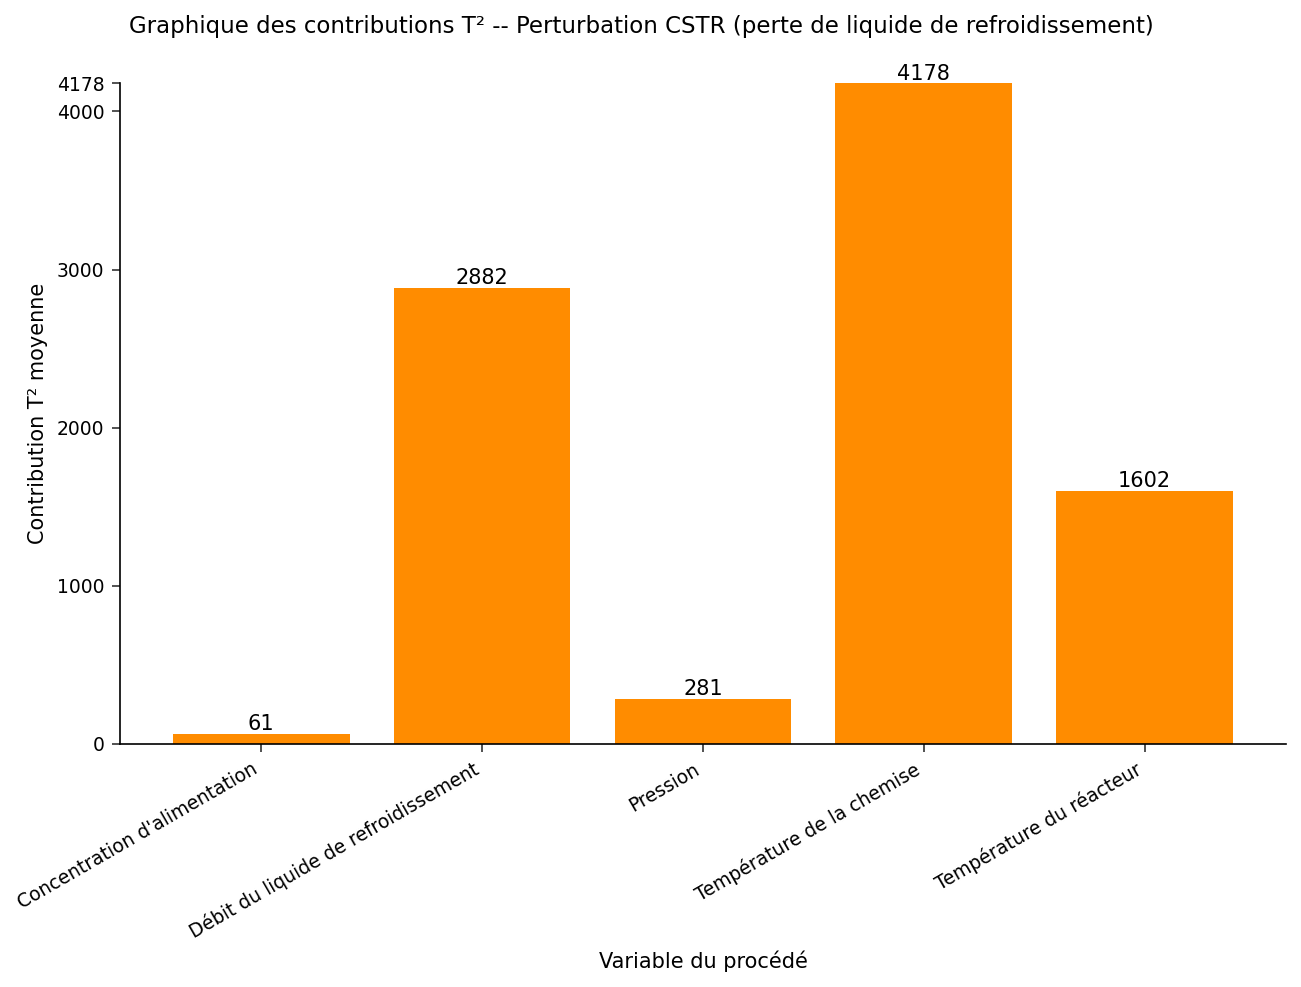

In [4]:
PROC SGPLOT DONNÉES=contrib_ranked;
  VBAR variable / RESPONSE=mean_contrib
                  fillattrs=(color=darkorange)
                  DATALABEL;
  XAXIS ÉTIQUETTE='Variable du procédé';
  YAXIS ÉTIQUETTE='Contribution T² moyenne';
  TITRE 'Graphique des contributions T² -- Perturbation CSTR (perte de liquide de refroidissement)';
EXÉCUTER;


## Étape 5 — Chronologie de contrôle du *T*-carré

Tracer le *T*-carré de chaque observation par rapport à la limite de
contrôle du modèle montre que l'excursion est continue : chaque
observation de l'incident se situe des ordres de grandeur au-dessus de
la ligne de référence de la limite. Il n'y a aucune récupération dans
la fenêtre observée, ce qui est cohérent avec une panne matérielle qui
persiste jusqu'à ce que le sous-système de refroidissement soit
réparé.



NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


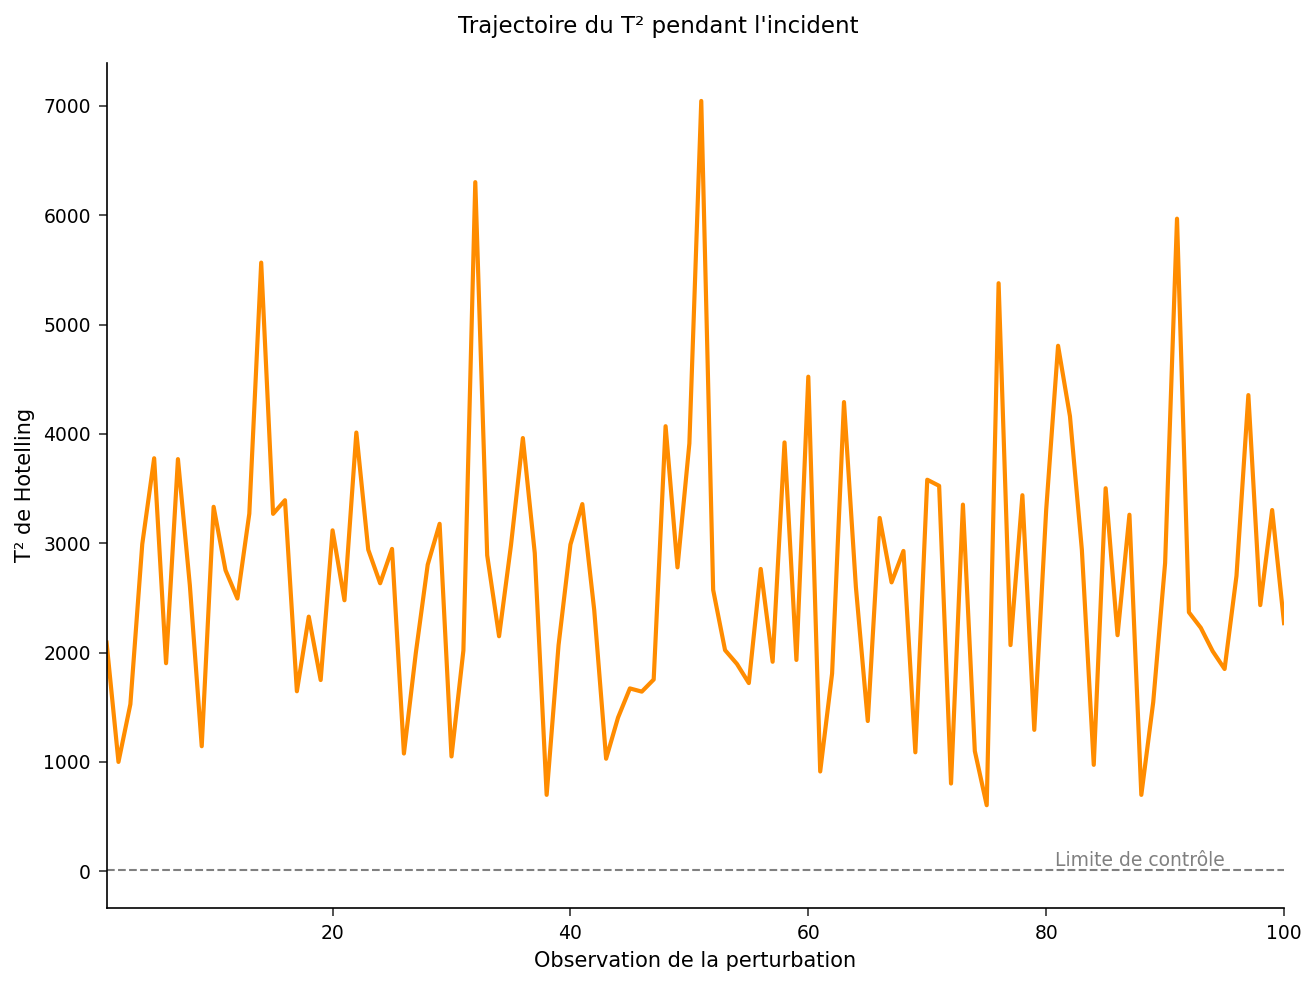

In [5]:
PROC SGPLOT DONNÉES=reactor_scores;
  SERIES x=_OBS y=_TSQUARED / LINEATTRS=(color=darkorange thickness=2);
  REFLINE 14.87 / AXIS=y
                  ÉTIQUETTE='Limite de contrôle'
                  LINEATTRS=(pattern=dash color=gray);
  XAXIS ÉTIQUETTE='Observation de la perturbation';
  YAXIS ÉTIQUETTE='T² de Hotelling';
  TITRE "Trajectoire du T² pendant l'incident";
EXÉCUTER;


## Constats et mesures correctives

- **Principaux facteurs** : `jacket_temp`, `coolant_flow` et
  `reactor_temp` représentent à eux trois l'essentiel du signal
  *T*-carré ; leurs contributions moyennes sont deux à trois ordres de
  grandeur au-dessus de `feed_conc` et `pressure`.
- **Cause racine** : une perte d'alimentation en liquide de
  refroidissement. `coolant_flow` est la seule variable *manipulée*
  des trois — les hausses de température sont des conséquences en
  aval de la perte de refroidissement, donc la défaillance actionnable
  est le sous-système de refroidissement.
- **État du contrôle** : les 100 observations de l'incident dépassent
  toutes la limite *T*-carré, indiquant une excursion soutenue plutôt
  qu'un phénomène transitoire.
- **Action corrective** : inspecter et remettre à neuf la pompe de
  refroidissement ; ajouter un transmetteur de débit de refroidissement
  redondant afin qu'une future perte d'alimentation soit détectée par
  une alarme univariée avant qu'elle ne se propage à la boucle de
  température.


## Exporter les contributions classées

Le tableau des contributions classées est écrit au format CSV pour le
rapport post-incident et les tableaux de bord en aval.


In [6]:
PROC EXPORT DONNÉES=contrib_ranked
            OUTFILE='reactor_upset_contributions.csv'
            DBMS=csv REMPLACER;
EXÉCUTER;



NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Optimisé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>